# Project 7 — Comparing Regression Loss Functions

## Project Description


**Objective**: Build intuition for how different regression losses respond to prediction errors.

**Using NumPy and Matplotlib**:

- Generate a simple synthetic regression dataset.
- Create several sets of predictions:
  - Nearly perfect predictions,
  - Moderate errors,
  - A few extreme outliers.
- Compute MSE, MAE, and Huber Loss for each prediction set.
- Plot the loss values and compare how each loss reacts as prediction errors increase.
- Write a short discussion explaining which loss would be most appropriate in each scenario and why.

The goal is to understand that choosing a loss function is not just a mathematical detail—it shapes how a model learns.

## My Solution

In [1]:
import numpy as np

from matplotlib.figure import Figure
from IPython.display import display
import seaborn as sns

In [23]:
np.random.seed(42)
n_samples = 100

y_true = np.linspace(0, 10, n_samples)


y_pred_nearly_perfect = y_true + np.random.normal(0, 0.2, n_samples)

y_pred_moderate = y_true + np.random.normal(0, 1.5, n_samples)

y_pred_outliers = y_pred_nearly_perfect.copy()
y_pred_outliers[[10, 50, 90]] += [25.0, -30.0, 35.0]

scenarios = {
    "Nearly Perfect": y_pred_nearly_perfect,
    "Moderate Errors": y_pred_moderate,
    "With Extreme Outliers": y_pred_outliers,
}

print(y_pred_outliers.shape)

(100,)


In [24]:
def squared_error(y_true, y_pred):
    squared_error = (y_true - y_pred) ** 2
    return squared_error, np.mean(squared_error)


def absolute_error(y_true, y_pred):
    absolute_error = np.abs(y_true - y_pred)
    return absolute_error, np.mean(absolute_error)


def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta

    squared_loss = 0.5 * (error**2)
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    huber_loss = np.where(is_small_error, squared_loss, linear_loss)
    print("**", huber_loss.shape)

    return huber_loss, np.mean(huber_loss)

In [21]:
print(f"{'Scenario':<22} | {'MSE':<10} | {'MAE':<10} | {'Huber (δ=1)':<10}")
print("-" * 60)

for name, y_pred in scenarios.items():
    mse = squared_error(y_true, y_pred)[1]
    mae = absolute_error(y_true, y_pred)[1]
    huber = huber_loss(y_true, y_pred, delta=1.0)[1]
    print(f"{name:<22} | {mse:<10.3f} | {mae:<10.3f} | {huber:<10.3f}")

Scenario               | MSE        | MAE        | Huber (δ=1)
------------------------------------------------------------
Nearly Perfect         | 0.033      | 0.145      | 0.017     
Moderate Errors        | 2.027      | 1.134      | 0.728     
With Extreme Outliers  | 27.461     | 1.041      | 0.900     


In [5]:
def get_square_axis_limits_data_focused(x, y, margin=0.1):
    """Calculates symmetric x and y limits with an added margin to create a square

    plot frame covering all data points.

    Parameters:
    -----------
    x : array-like
        Feature values for x-axis.
    y : array-like
        Feature values for y-axis.
    margin : float, default=0.1
        Percentage margin (0.1 = 10%) to pad around the global min and max.

    Returns:
    --------
    min_limit : float
        Lower bound for both set_xlim and set_ylim.
    max_limit : float
        Upper bound for both set_xlim and set_ylim.
    """
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    # 1. Find the global min and max across BOTH features
    global_min = min(np.min(x_arr), np.min(y_arr))
    global_max = max(np.max(x_arr), np.max(y_arr))

    # 2. Calculate span and margin padding
    data_span = global_max - global_min
    # Fallback to prevent 0 division if all data points are identical
    padding = data_span * margin if data_span > 0 else 1.0

    # 3. Apply padding
    min_limit = global_min - padding
    max_limit = global_max + padding

    return min_limit, max_limit

** (100,)
** (100,)
** (100,)


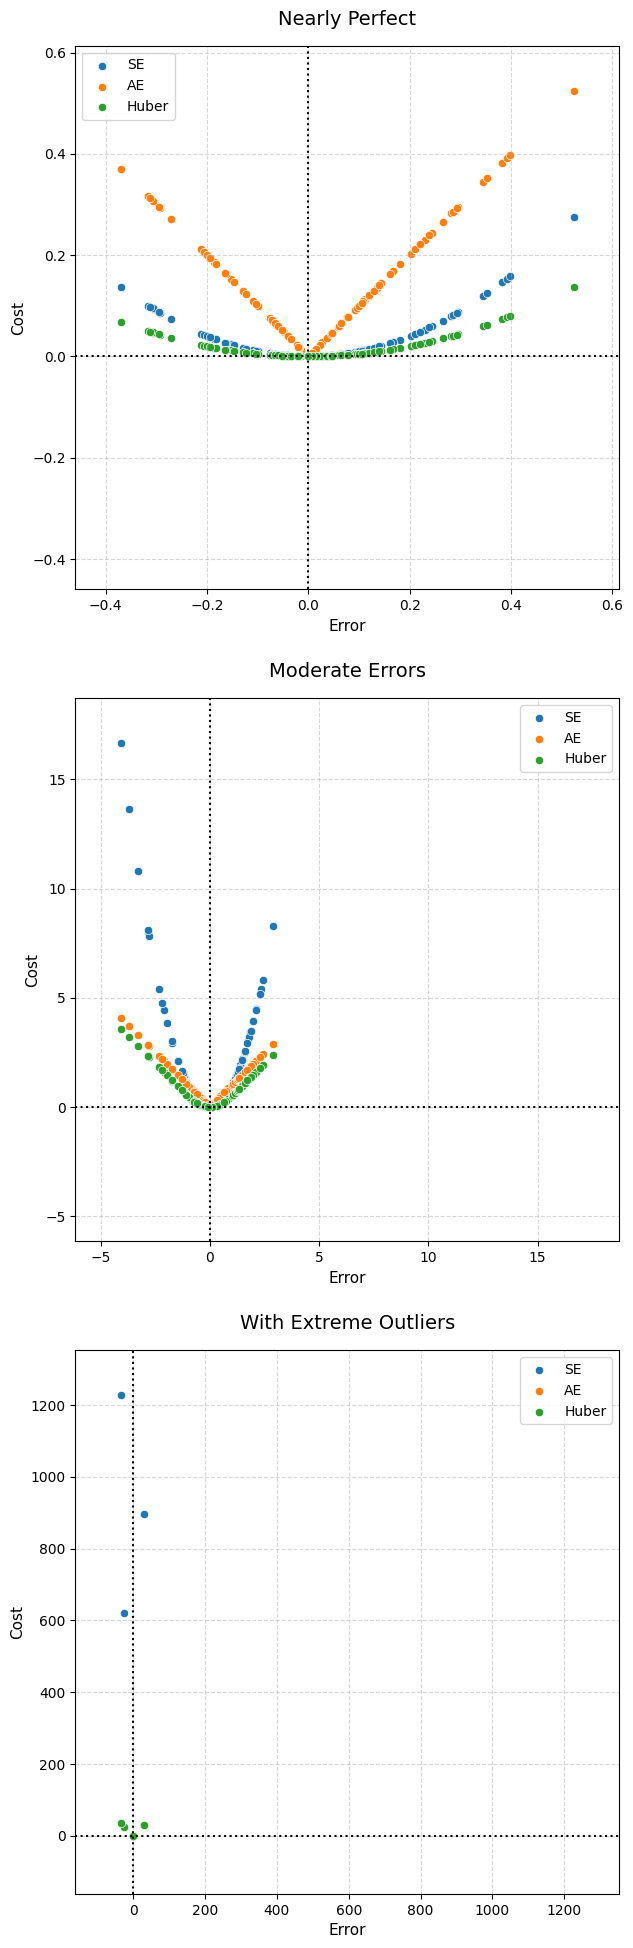

In [25]:
cost_vs_error_plots = Figure(figsize=(8, 24))

axes_for_nearly_perfect_prediction = cost_vs_error_plots.add_subplot(3, 1, 1)
axes_for_moderate_prediction = cost_vs_error_plots.add_subplot(3, 1, 2)
axes_for_prediction_with_few_outliers = cost_vs_error_plots.add_subplot(3, 1, 3)

axes_set = [axes_for_nearly_perfect_prediction, axes_for_moderate_prediction, axes_for_prediction_with_few_outliers]

for axes, (name, y_pred) in zip(axes_set, scenarios.items()):

    error = y_true - y_pred # error

    cost_se = squared_error(y_true, y_pred)[0]
    cost_ae = absolute_error(y_true, y_pred)[0]
    cost_huber = huber_loss(y_true, y_pred)[0]

    sns.scatterplot(x=error, y=cost_se, ax=axes, label="SE")
    sns.scatterplot(x=error, y=cost_ae, ax=axes, label="AE")
    sns.scatterplot(x=error, y=cost_huber, ax=axes, label="Huber")


    min_limit, max_limit = get_square_axis_limits_data_focused(error, [cost_se, cost_ae, cost_huber], margin=0.1)
           
    axes.set_title(name, fontsize=14, pad=15)
    axes.set_xlabel("Error", fontsize=11)
    axes.set_ylabel("Cost", fontsize=11)
    axes.axhline(0, color="black", linestyle=":", linewidth=1.5, zorder=2)
    axes.axvline(0, color="black", linestyle=":", linewidth=1.5, zorder=2)
    axes.grid(True, linestyle="--", alpha=0.5)
    axes.set_aspect("equal", adjustable="box")
    axes.set_xlim(min_limit, max_limit)
    axes.set_ylim(min_limit, max_limit)
    
cost_vs_error_plots.canvas.draw()
display(cost_vs_error_plots)

## Short Discussion

- When to use MSE: Best when errors are normally distributed and I want to heavily penalize large mistakes (e.g., safety-critical systems where large errors are intolerable).

- When to use MAE: Best when my dataset contains dirty data or unexpected outliers (e.g., sensor glitches, corrupt data entry) that shouldn't dictate model learning.

- When to use Huber Loss: Best when I want the smooth optimization properties of MSE around small errors, but need robustness against extreme outliers without letting them blow up gradient updates.

## What ChatGPT Expected Me to Learn from this Project

Project 7 was about developing an intuition for loss functions.

I hoped you observed that:

- MSE increases rapidly when large errors appear.
- MAE is more tolerant of outliers.
- Huber Loss behaves like MSE for small errors and MAE for large ones.
- The choice of loss function changes the optimization problem itself.

The most important takeaway is:
> A model learns what its loss function encourages it to learn.